# Trabajo Práctico 1

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from PIL import Image

## Funciones Auxiliares

In [17]:
def get_model(): # Función para recibir un modelo de regresion logaritmica
    lr_model = LogisticRegression(max_iter=5000)
    return lr_model


def train(X_train, y_train, lr_model): # Función para entrenar
    # Entrenamiento del modelo
    lr_model.fit(X_train, y_train)


def test(X_test, y_test, lr_model): # Función para testear
    y_pred = lr_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc


def get_train_data( # Data para entrenamiento con parametros por default
    ruta_train="./dataset_tp1/train/", ruta_train_labels="dataset_tp1/train_labels.csv"
):
    X_train = []
    for archivo in sorted(os.listdir(ruta_train)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_train + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_train.append(imagen_array)

    X_train = np.array(X_train)

    train_labels = pd.read_csv(ruta_train_labels)
    y_train = train_labels["clase"].to_numpy()

    return X_train, y_train


def get_test_data( # Data para tests con parámetros x default
    ruta_test="./dataset_tp1/test/", ruta_test_labels="dataset_tp1/test_labels.csv"
):
    # Validación del modelo
    X_test = []
    for archivo in sorted(os.listdir(ruta_test)):
        if archivo.endswith(".png"):
            ruta_imagen = ruta_test + archivo
            imagen = Image.open(ruta_imagen)
            imagen_array = np.array(imagen).flatten()
            X_test.append(imagen_array)
    X_test = np.array(X_test)

    test_labels = pd.read_csv(ruta_test_labels)
    y_test = test_labels["clase"].to_numpy()
    return X_test, y_test

def USV(X):  # Ver diapos 6. Análisis de componentes principales
    ux = X.mean(axis=0)
    Xc = X - ux

    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    V = Vt.T
    S = np.diag(s)

    return U, S, V, ux

def proyectar_k(X, mu, V, k):
    Xc = X - mu
    Vk = V[:,:k]

    return Xc @ Vk

def scatter1b(X_test, y_test):
    sanos = []
    enfermos = []
    for i in range(len(X_test)):
        if y_test[i] == 0:
            sanos.append(X_test[i])
        else:
            enfermos.append(X_test[i])

    sanos = np.array(sanos)
    enfermos = np.array(enfermos)

    plt.scatter(sanos[:,0],sanos[:,1],c="blue",label="Pulmones sanos")
    plt.scatter(enfermos[:,0],enfermos[:,1],c="red",label="Pulmones enfermos")
    plt.ylabel("Componente 2")
    plt.xlabel("Componente 1")
    plt.title("Análisis de 2 componentes principales")
    plt.legend()
    plt.show()

## Ejercicio 1

Accuracy antes de aplicar PCA: 0.8183760683760684


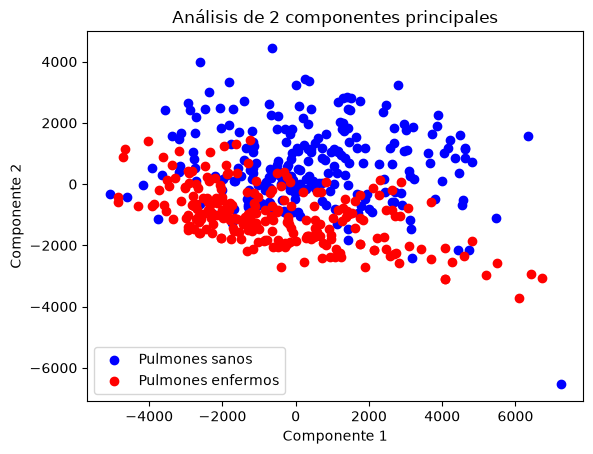

c:\Users\tomiv\Downloads\TP1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


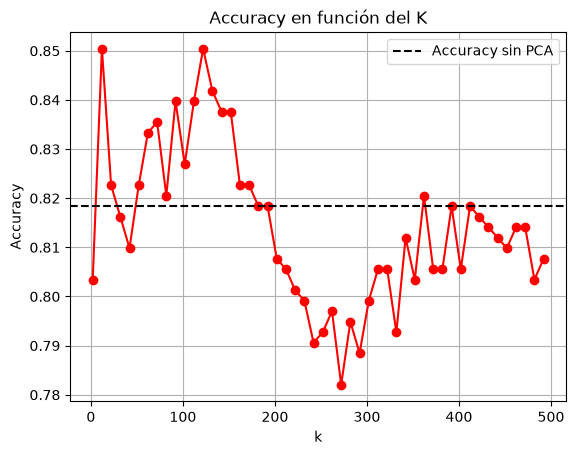

In [18]:
X_train, y_train = get_train_data()
X_test, y_test = get_test_data()

# 1.a)-------------SIN PCA-------------------------------------


lr_model = get_model()

train(X_train, y_train, lr_model)

acc = test(X_test, y_test, lr_model)

print(f"Accuracy antes de aplicar PCA: {acc}")


# 1.b)----------PROYECCIONES + SCATTER-------------------------


U, S, V, ux= USV(
    X_train
)  # Recibimos U, S, V, ux
X_test_K2 = proyectar_k(X_test, ux, V, 2) # Proyectamos el conjunto de test sobre la matriz de proyeccion
scatter1b(X_test_K2, y_test)



# 1.c)----------CON PCA + DISTINTOS K--------------
ks = []
accs = []

for k in range(2,500,10):
    ks.append(k)
    lr_model_k = get_model()
    X_train_k = proyectar_k(X_train, ux, V, k)
    X_test_k = proyectar_k(X_test, ux, V, k)
    train(X_train_k,y_train,lr_model_k)
    acc_k = test(X_test_k,y_test,lr_model_k)
    accs.append(acc_k)

ks = np.array(ks)
accs = np.array(accs)

plt.plot(ks,accs,"ro-")
plt.title("Accuracy en función del K")
plt.axhline(acc, c="black",linestyle="--",label="Accuracy sin PCA")
plt.ylabel("Accuracy")
plt.xlabel("k")
plt.legend()
plt.grid()
plt.show()

## Ejercicio 2

Scatter con p= 0.1


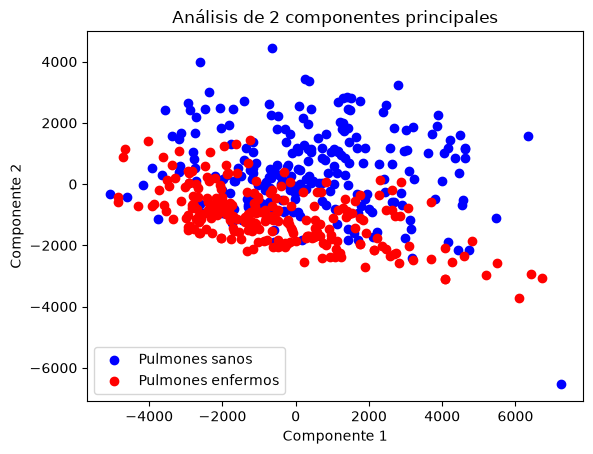

Scatter con p= 0.2


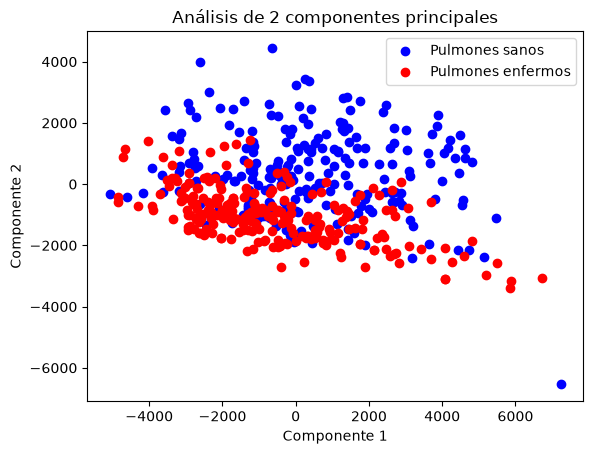

Scatter con p= 0.3


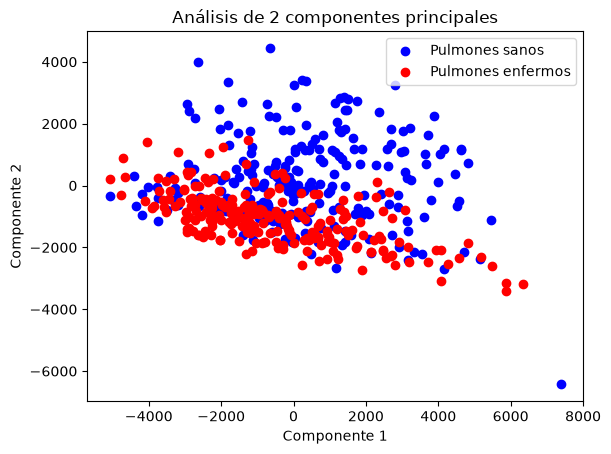

Scatter con p= 0.4


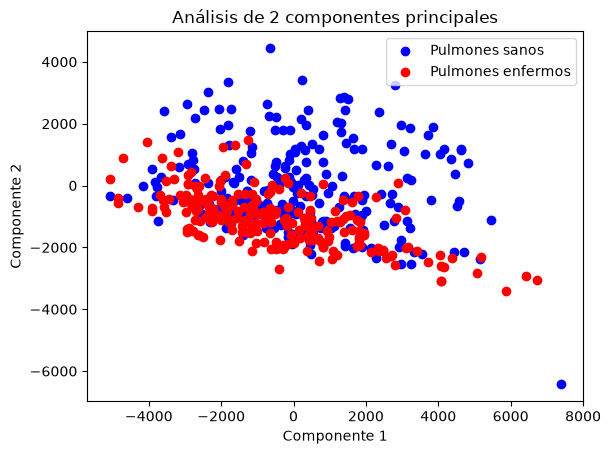

Scatter con p= 0.5


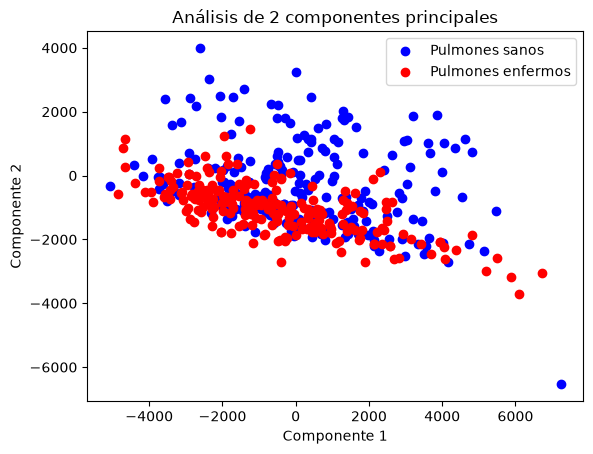

Scatter con p= 0.6


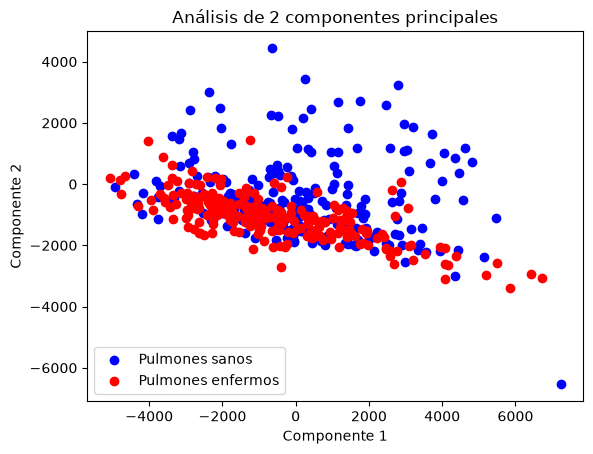

Scatter con p= 0.7


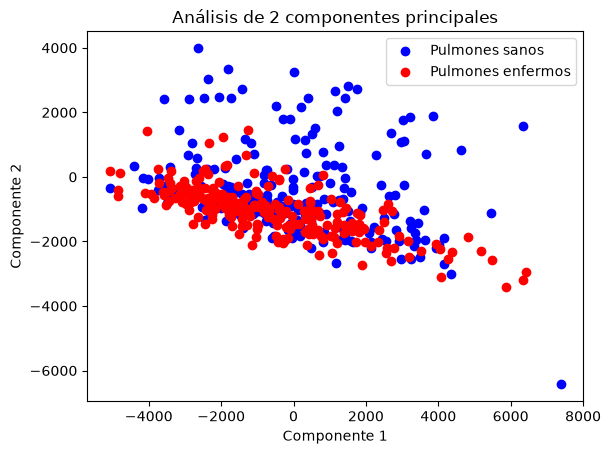

Scatter con p= 0.8


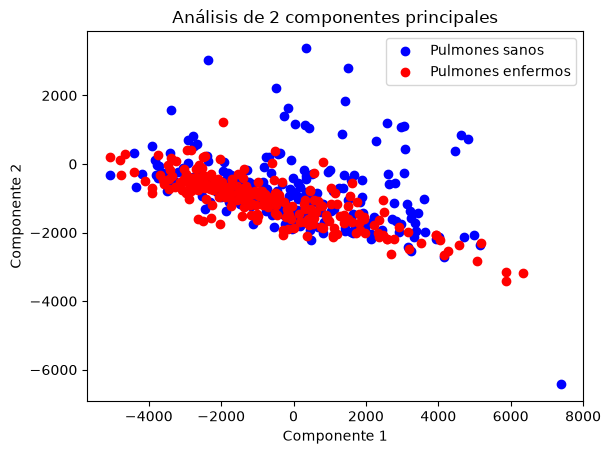

Scatter con p= 0.9


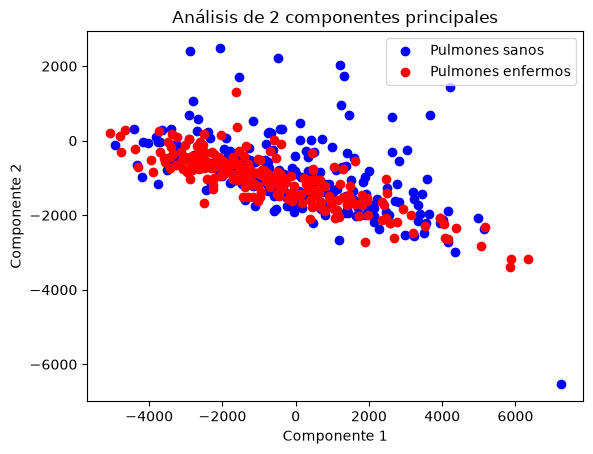

In [ ]:
'''
Reutilizo variables del punto 1
X_train, y_train, X_test, y_test
ux: Media
V: Matriz de componentes principales
'''
X_train_K2 = proyectar_k(X_train, ux, V, 2)
X_test_K2 = proyectar_k(X_test, ux, V, 2)

lr_model_MC = get_model()
train(X_train_K2, y_train, lr_model_MC)

A0 = test(X_test_K2, y_test, lr_model_MC)

# Perturbacion: rotacion de imagenes con probabilidad p
def perturbaciones(X_test, p):
    X_test_perturbado = X_test.copy()
    for i in range(len(X_test_perturbado)):
        if np.random.rand() < p:
            img = X_test_perturbado[i].reshape(128,128)
            img_rotada = np.rot90(img, 2)
            X_test_perturbado[i] = img_rotada.flatten()
    return X_test_perturbado

N_mc = 1000
L_p = [] # Perdida, cuanto se aleja el accuracy
tolerancia = 0.1

acc_promedios = []
prob_perdida_supera_01 = []
accuracies_por_p = {}

p_values = np.arange(0.1, 1.0, 0.1)
for proba in p_values:
    proba = round(proba,1)
    acc_mc = []
    for i in range(N_mc):
        X_test_mod = perturbaciones(X_test, proba)
        X_test_K2_mod = proyectar_k(X_test_mod, ux, V, 2)

        acc_local = test(X_test_K2_mod, y_test, lr_model_MC)
        acc_mc.append(acc_local)

        # a - Scatter solo una vez por cada proba distinta
        if i == 0:
            print(f"Scatter con p= {proba}")
            scatter1b(X_test_K2_mod, y_test)

    # b - Metodo Montecarlo - Valor medio
    acc_mc = np.array(acc_mc)
    E_Ap = np.mean(acc_mc)

    # c - Proba de superar tolerancia
    L_p = A0 - acc_mc
    Perdida_mayor = np.mean(L_p>tolerancia)

    acc_promedios.append(E_Ap)
    prob_perdida_supera_01.append(Perdida_mayor)
    accuracies_por_p[proba] = acc_mc


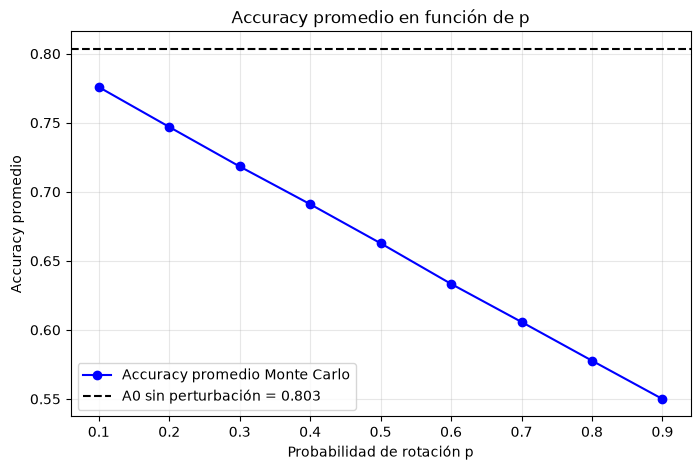

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(p_values, acc_promedios, "o-", color="blue", label="Accuracy promedio Monte Carlo")
plt.axhline(A0, linestyle="--", color="black", label=f"A0 sin perturbación = {A0:.3f}")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Accuracy promedio")
plt.title("Accuracy promedio en función de p")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

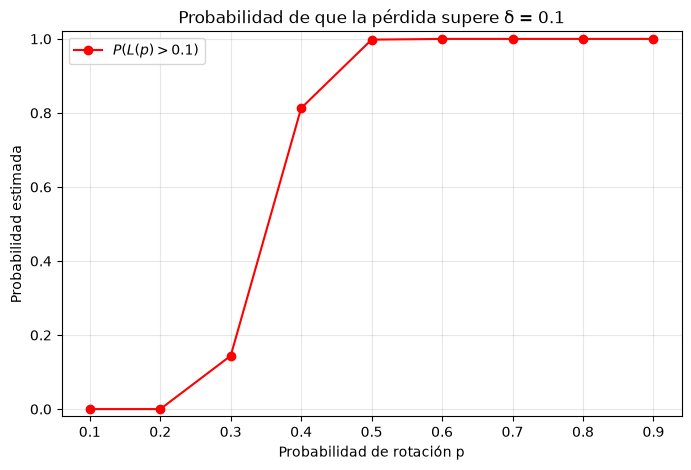

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(p_values, prob_perdida_supera_01, "o-", color="red", label=r"$P(L(p) > 0.1)$")
plt.xlabel("Probabilidad de rotación p")
plt.ylabel("Probabilidad estimada")
plt.title("Probabilidad de que la pérdida supere δ = 0.1")
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.show()